## Multiclass Classification: ML Algorithm Predicting Student Status (Dropout, Enrolled, Graduate)

DATASCI 347: Machine Learning I

Group member: Grayson Stone, Eric Wang, Joy Cheng, Samuel Chernoff

In [164]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

### Descriptive Statistics

In [165]:
# Load csv data
df = pd.read_csv('data.csv', sep=';')

# Examine the shape and structure
print("Dataset Shape:", df.shape)
display(df.head())

print("Data Types:")
display(df.dtypes)

print("Missing Values:")
display(df.isnull().sum())

print("Target Distribution (count):")
display(df['Target'].value_counts())

Dataset Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Data Types:


Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

Missing Values:


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Target Distribution (count):


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

### Create Feature Sets

Define feature categories for progressive datasets.

In [166]:
# Demographic features only
demographic_features = [
    'Marital status', 'Application mode', 'Application order', 'Course', 
    'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)',
    'Nacionality', "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation", 'Admission grade',
    'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

# 1st semester academic performance
sem1_features = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)'
]

# 2nd semester academic performance
sem2_features = [
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)'
]

# Filter features to only include those in the dataset
available_cols = set(df.columns)
demographic_features = [f for f in demographic_features if f in available_cols]
sem1_features = [f for f in sem1_features if f in available_cols]
sem2_features = [f for f in sem2_features if f in available_cols]

# Create rename mapping for shorter column names
rename_mapping = {
    'Daytime/evening attendance\t': 'Attendance',
    'Previous qualification': 'Prev. Qual.',
    'Previous qualification (grade)': 'Qual. (grade)',
    'Nacionality': 'Nationality',
    "Mother's qualification": "Mother's qual.",
    "Father's qualification": "Father's qual.",
    "Mother's occupation": "Mother's occup.",
    "Father's occupation": "Father's occup.",
    'Admission grade': 'GPA',
    'Educational special needs': 'Special needs',
    'Tuition fees up to date': 'Tuition',
    'Scholarship holder': 'Scholarship',
    'Age at enrollment': 'Enroll age',
    'Unemployment rate': 'Unemp. rate',
    'Curricular units 1st sem (credited)': '1st sem (credited)',
    'Curricular units 1st sem (enrolled)': '1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)': '1st sem (eval)',
    'Curricular units 1st sem (approved)': '1st sem (approved)',
    'Curricular units 1st sem (grade)': '1st sem (grade)',
    'Curricular units 1st sem (without evaluations)': '1st sem (w/o eval.)',
    'Curricular units 2nd sem (credited)': '2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)': '2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)': '2nd sem (eval)',
    'Curricular units 2nd sem (approved)': '2nd sem (approved)',
    'Curricular units 2nd sem (grade)': '2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)': '2nd sem (w/o eval.)'
}

print("Numbers of features:")
print(f"  Demographic features: {len(demographic_features)}")
print(f"  1st semester features: {len(sem1_features)}")
print(f"  2nd semester features: {len(sem2_features)}")

# Create progressive feature sets
df_early = df[demographic_features + ['Target']].copy()
df_mid = df[demographic_features + sem1_features + ['Target']].copy()
df_full = df[demographic_features + sem1_features + sem2_features + ['Target']].copy()

# Apply column renaming
df_early = df_early.rename(columns=rename_mapping)
df_mid = df_mid.rename(columns=rename_mapping)
df_full = df_full.rename(columns=rename_mapping)

# Update feature lists with new names
demographic_features = [rename_mapping.get(f, f) for f in demographic_features]
sem1_features = [rename_mapping.get(f, f) for f in sem1_features]
sem2_features = [rename_mapping.get(f, f) for f in sem2_features]

print("\nFeature sets dimensions:")
print(f"  df_early (demographics only): {df_early.shape}")
print(f"  df_mid (demographics + 1st sem): {df_mid.shape}")
print(f"  df_full (demographic + 1st sem + 2nd sem): {df_full.shape}")

Numbers of features:
  Demographic features: 24
  1st semester features: 6
  2nd semester features: 6

Feature sets dimensions:
  df_early (demographics only): (4424, 25)
  df_mid (demographics + 1st sem): (4424, 31)
  df_full (demographic + 1st sem + 2nd sem): (4424, 37)


### Preprocessing

In [167]:
def preprocess_data(df):
    df_processed = df.copy()
    
    # Separate features and target
    target = df_processed['Target']
    X = df_processed.drop('Target', axis=1)
    
    # Encode categorical variables
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
    
    # Encode target variable
    le_target = LabelEncoder()
    target = le_target.fit_transform(target)
    label_encoders['Target'] = le_target
    
    return X, target, label_encoders

# Preprocess all three datasets
X_early, y, label_encoders_early = preprocess_data(df_early)
X_mid, _, label_encoders_mid = preprocess_data(df_mid)
X_full, _, label_encoders_full = preprocess_data(df_full)

# Store target encoder for reference
le_target = label_encoders_early.get('Target')

print("Dimension for each dataset:")
print(f"  X_early shape: {X_early.shape}")
print(f"  X_mid shape: {X_mid.shape}")
print(f"  X_full shape: {X_full.shape}")

Dimension for each dataset:
  X_early shape: (4424, 24)
  X_mid shape: (4424, 30)
  X_full shape: (4424, 36)


### Feature Analysis: Multicollinearity & Correlation

In [168]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

vif_results = {}
vif_early = compute_vif(X_early)
vif_mid = compute_vif(X_mid)
vif_full = compute_vif(X_full)

vif_results = {'early': vif_early, 'mid': vif_mid, 'full': vif_full}

print("VIF Summary (Multicollinearity Detection):")
print(f"  Early: Mean={vif_early['VIF'].mean():.2f}, Max={vif_early['VIF'].max():.2f}")
print(f"  Mid: Mean={vif_mid['VIF'].mean():.2f}, Max={vif_mid['VIF'].max():.2f}")
print(f"  Full: Mean={vif_full['VIF'].mean():.2f}, Max={vif_full['VIF'].max():.2f}")

VIF Summary (Multicollinearity Detection):
  Early: Mean=15.84, Max=128.60
  Mid: Mean=17.58, Max=129.28
  Full: Mean=26.52, Max=180.79


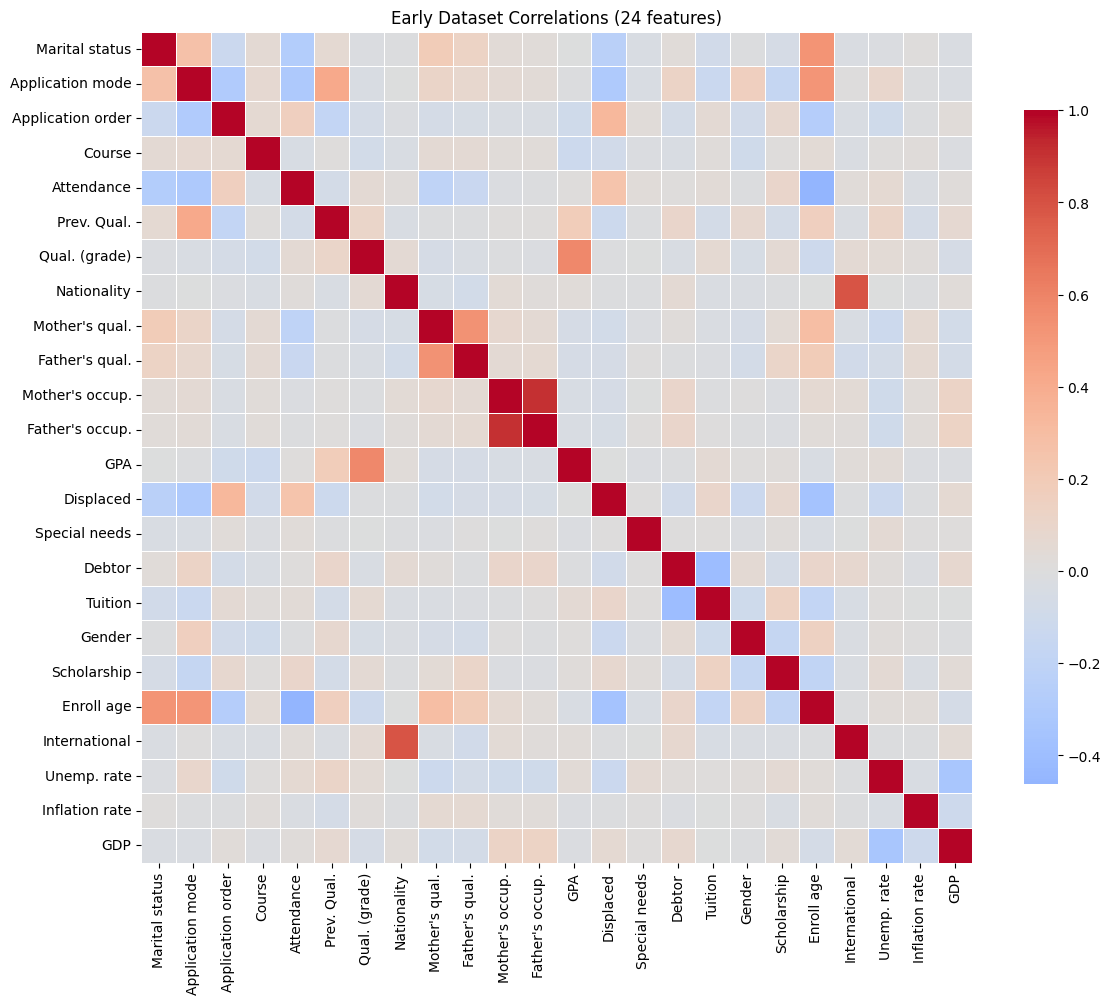

In [169]:
corr_early = X_early.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_early, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title(f'Early Dataset Correlations ({X_early.shape[1]} features)')
plt.tight_layout()
plt.show()

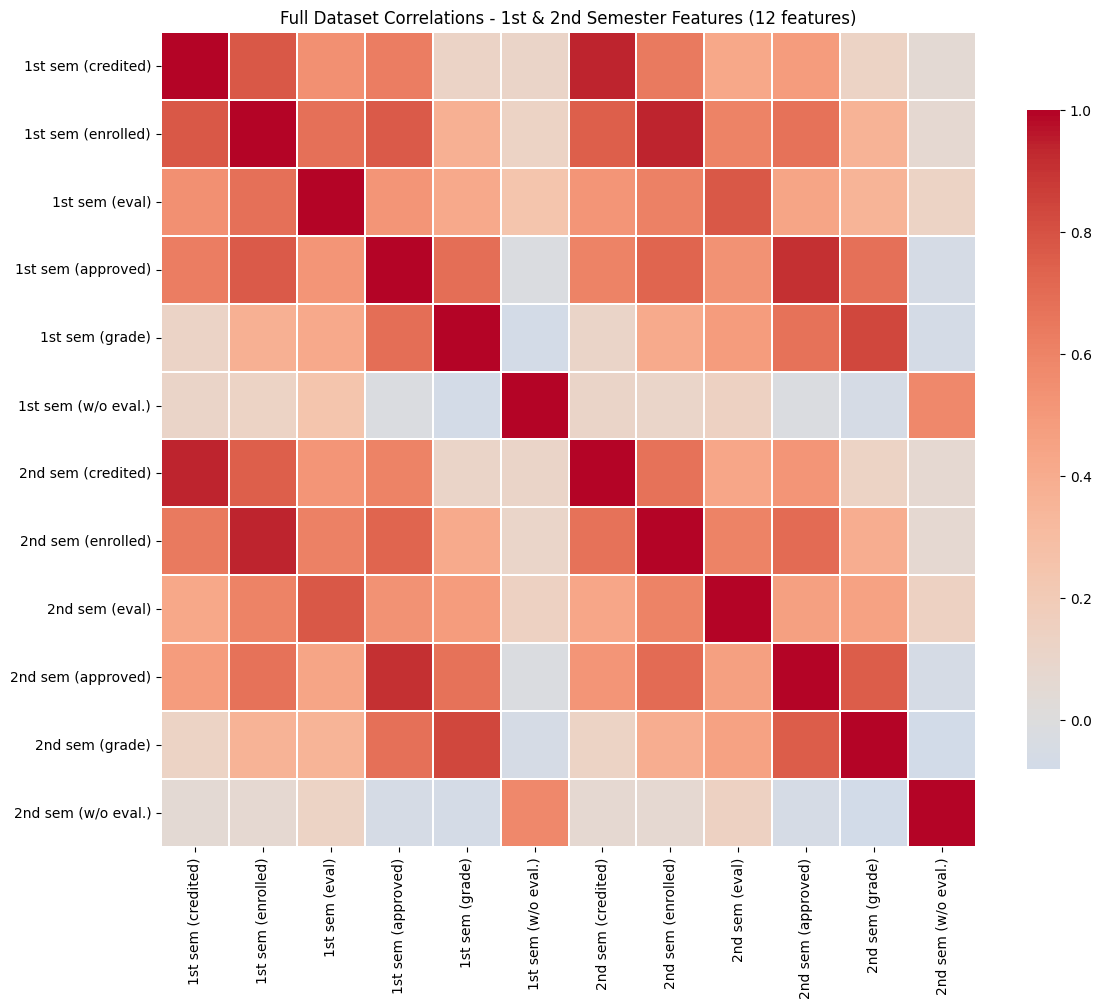

In [170]:
# corr_mid was ignored as corr_full captures all
corr_full = X_full[sem1_features + sem2_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_full, cmap='coolwarm', center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title(f'Full Dataset Correlations - 1st & 2nd Semester Features ({len(sem1_features + sem2_features)} features)')
plt.tight_layout()
plt.show()

### Split Data

In [171]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Stratified split to maintain class distribution
X_early_train, X_early_test, y_train, y_test = train_test_split(
    X_early, y, test_size=0.2, random_state=42, stratify=y
)

X_mid_train, X_mid_test, y_train_mid, y_test_mid = train_test_split(
    X_mid, y, test_size=0.2, random_state=42, stratify=y
)

X_full_train, X_full_test, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for logistic regression
scaler_early = StandardScaler()
X_early_train_scaled = scaler_early.fit_transform(X_early_train)
X_early_test_scaled = scaler_early.transform(X_early_test)

scaler_mid = StandardScaler()
X_mid_train_scaled = scaler_mid.fit_transform(X_mid_train)
X_mid_test_scaled = scaler_mid.transform(X_mid_test)

scaler_full = StandardScaler()
X_full_train_scaled = scaler_full.fit_transform(X_full_train)
X_full_test_scaled = scaler_full.transform(X_full_test)

print(f"Train size: {len(X_early_train)} | Test size: {len(X_early_test)} (80-20 split)")
print(f"\nClass distribution in training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique_train, counts_train):
    print(f"  Class {cls}: {cnt}")
print(f"\nClass distribution in test set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique_test, counts_test):
    print(f"  Class {cls}: {cnt}")

Train size: 3539 | Test size: 885 (80-20 split)

Class distribution in training set:
  Class 0: 1137
  Class 1: 635
  Class 2: 1767

Class distribution in test set:
  Class 0: 284
  Class 1: 159
  Class 2: 442


### Hyperparameter Tuning

In [172]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, learning_curve
import time

# Logistic Regression hyperparameters
param_grid_logreg_ridge = {
    'C': [0.001, 0.01, 0.1, 1.0, 10, 100],
    'solver': ['lbfgs'],
    'max_iter': [500, 1000, 2000]
}

param_grid_logreg_lasso = {
    'C': [0.001, 0.01, 0.1, 1.0, 10, 100],
    'solver': ['liblinear'],
    'max_iter': [500, 1000, 2000]
}

# Random Forest hyperparameters
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# XGBoost hyperparameters
param_grid_xgb = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'n_estimators': [100, 150, 200],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 1, 5]
}

print("Search Space Sizes:")
print(f"  Logistic Regression (Ridge): {np.prod([len(v) for v in param_grid_logreg_ridge.values()])} combinations")
print(f"  Logistic Regression (Lasso): {np.prod([len(v) for v in param_grid_logreg_lasso.values()])} combinations")
print(f"  Random Forest: {np.prod([len(v) for v in param_grid_rf.values()])} combinations")
print(f"  XGBoost: {np.prod([len(v) for v in param_grid_xgb.values()])} combinations")

Search Space Sizes:
  Logistic Regression (Ridge): 18 combinations
  Logistic Regression (Lasso): 18 combinations
  Random Forest: 270 combinations
  XGBoost: 972 combinations


In [173]:
def plot_learning_curves(estimator, X, y, cv, title, axes=None):
    """Generate learning curves to diagnose bias/variance issues."""
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 6))
    
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    
    train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
    val_mean, val_std = np.mean(val_scores, axis=1), np.std(val_scores, axis=1)
    
    # Plot training and validation curves
    axes.plot(train_sizes, train_mean, 'o-', color='#2E86AB', label='Training score', linewidth=2)
    axes.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2E86AB')
    
    axes.plot(train_sizes, val_mean, 'o-', color='#A23B72', label='Validation score', linewidth=2)
    axes.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#A23B72')
    
    axes.set_xlabel('Training Set Size', fontsize=11)
    axes.set_ylabel('F1 Score (Weighted)', fontsize=11)
    axes.set_title(title, fontsize=12, fontweight='bold')
    axes.legend(loc='best', fontsize=10)
    axes.grid(alpha=0.3)
    
    # Diagnose bias/variance trade-off
    gap = val_mean[-1] - train_mean[-1]
    diagnosis = ("High Variance (Overfitting)" if gap > 0.05 
                 else "High Bias (Underfitting)" if train_mean[-1] < 0.70 
                 else "Good Fit")
    
    axes.text(0.5, 0.05, f"Gap: {gap:.3f} | {diagnosis}", 
             transform=axes.transAxes, ha='center', fontsize=9, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    return train_mean, train_std, val_mean, val_std

In [174]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import time

# Initialize
tuning_results, best_models_tuned = {}, {}
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Build datasets dictionary
datasets_dict = {}
for dataset_name, (X_s_train, X_s_test, X_u_train, X_u_test, y_tr, y_te) in [
    ('early', (X_early_train_scaled, X_early_test_scaled, X_early_train, X_early_test, y_train, y_test)),
    ('mid', (X_mid_train_scaled, X_mid_test_scaled, X_mid_train, X_mid_test, y_train_mid, y_test_mid)),
    ('full', (X_full_train_scaled, X_full_test_scaled, X_full_train, X_full_test, y_train_full, y_test_full))
]:
    datasets_dict[dataset_name] = {
        'scaled': {'X_train': X_s_train, 'X_test': X_s_test, 'y_train': y_tr, 'y_test': y_te},
        'unscaled': {'X_train': X_u_train, 'X_test': X_u_test, 'y_train': y_tr, 'y_test': y_te}
    }

# Tuning function
def tune_model(alg_name, dataset_name, estimator, params, scale_type, use_grid=True, n_iter=20):
    X = datasets_dict[dataset_name][scale_type]['X_train']
    y = datasets_dict[dataset_name][scale_type]['y_train']
    model_key = f'{alg_name}_{dataset_name}'
    
    start = time.time()
    search = (GridSearchCV(estimator, params, cv=inner_cv, scoring='f1_weighted', n_jobs=-1, verbose=0) 
              if use_grid 
              else RandomizedSearchCV(estimator, params, n_iter=n_iter, cv=inner_cv, scoring='f1_weighted', 
                                      n_jobs=-1, verbose=0, random_state=42))
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        search.fit(X, y)
    
    elapsed = time.time() - start
    best_models_tuned[model_key] = search.best_estimator_
    tuning_results[model_key] = {'best_params': search.best_params_, 'best_cv_score': search.best_score_, 'time': elapsed}
    print(f"  {model_key:25s} | F1: {search.best_score_:.4f} | Time: {elapsed:.1f}s")

# Algorithms
algorithms = [
    ('LogReg_Ridge', LogisticRegression(penalty='l2', random_state=42, max_iter=1000), param_grid_logreg_ridge, 'scaled', True),
    ('LogReg_Lasso', LogisticRegression(penalty='l1', solver='liblinear', random_state=42), param_grid_logreg_lasso, 'scaled', True),
    ('RandomForest', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1), param_grid_rf, 'unscaled', False),
    ('XGBoost', xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42, n_jobs=-1, verbosity=0), param_grid_xgb, 'unscaled', False),
]

for alg_name, estimator, params, scale_type, use_grid in algorithms:
    n_iter = 25 if 'XGBoost' in alg_name else 20 if not use_grid else None
    print(f"\n{alg_name}\n" + "-"*80)
    for dataset_name in ['early', 'mid', 'full']:
        tune_model(alg_name, dataset_name, estimator, params, scale_type, use_grid, n_iter)


LogReg_Ridge
--------------------------------------------------------------------------------
  LogReg_Ridge_early        | F1: 0.5741 | Time: 2.6s
  LogReg_Ridge_mid          | F1: 0.7097 | Time: 0.1s
  LogReg_Ridge_full         | F1: 0.7510 | Time: 0.1s

LogReg_Lasso
--------------------------------------------------------------------------------
  LogReg_Lasso_early        | F1: 0.5717 | Time: 0.2s
  LogReg_Lasso_mid          | F1: 0.7031 | Time: 0.3s
  LogReg_Lasso_full         | F1: 0.7409 | Time: 0.8s

RandomForest
--------------------------------------------------------------------------------
  RandomForest_early        | F1: 0.6264 | Time: 2.7s
  RandomForest_mid          | F1: 0.7338 | Time: 3.1s
  RandomForest_full         | F1: 0.7677 | Time: 2.8s

XGBoost
--------------------------------------------------------------------------------
  XGBoost_early             | F1: 0.6267 | Time: 2.5s
  XGBoost_mid               | F1: 0.7416 | Time: 2.4s
  XGBoost_full              | F

#### Learning Curves (Bias-Variance Diagnosis)

High Variance: Large gap between train and validation curves → model overfits

High Bias: Both train and validation curves low → model underfits

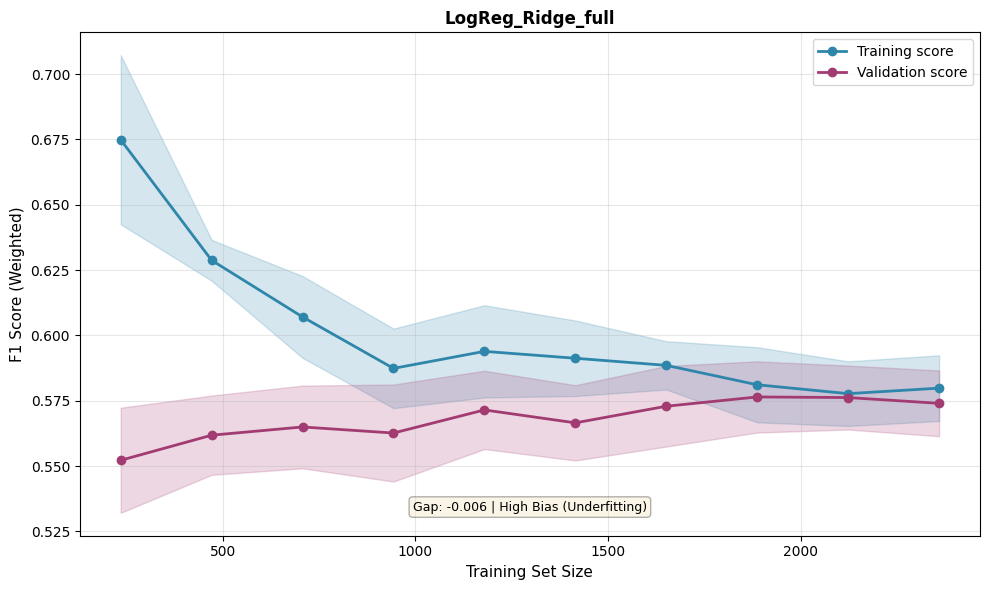

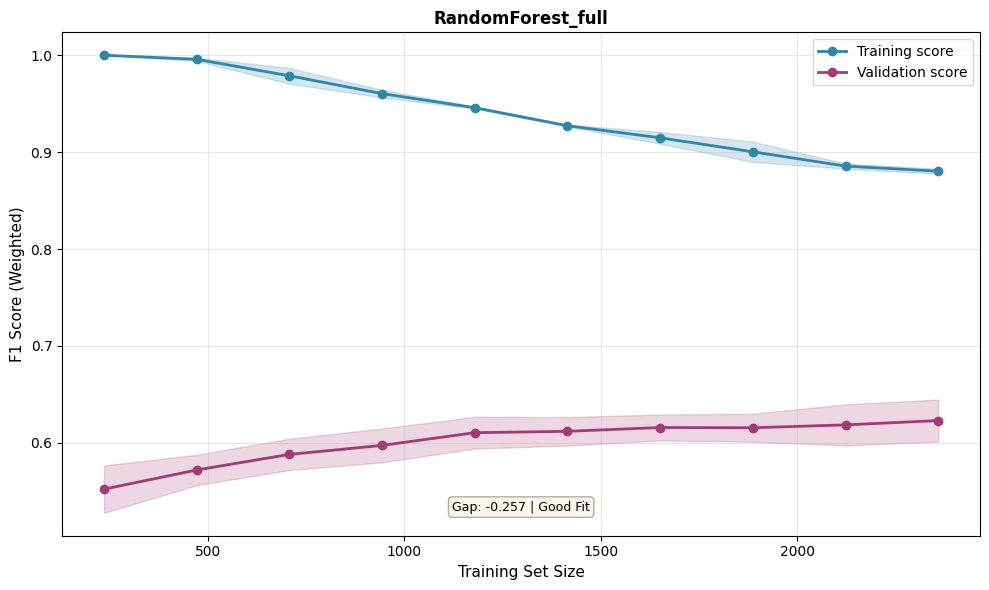

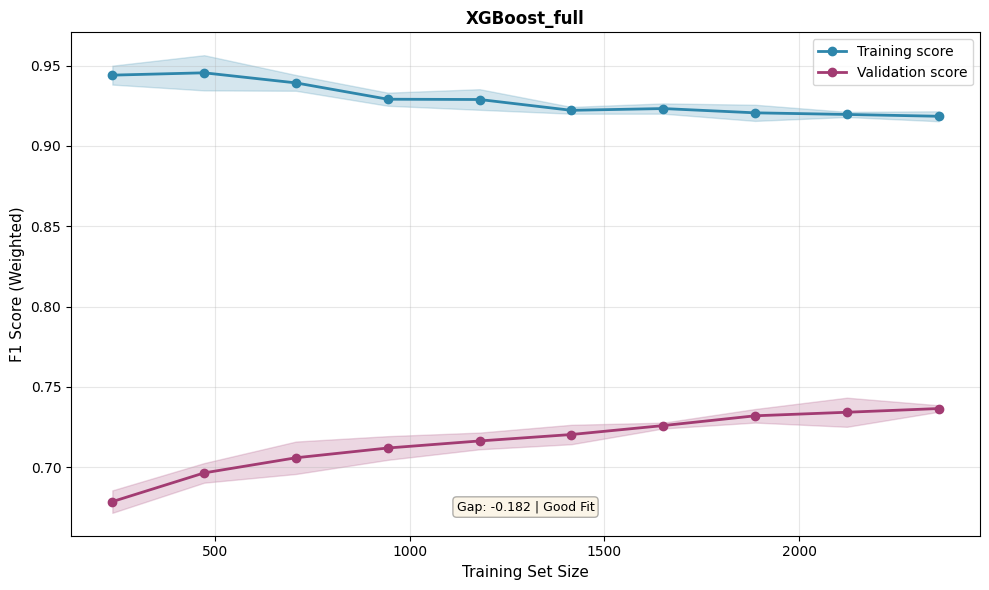

In [175]:
# Select representative models for learning curves
lc_models = {
    'LogReg_Ridge_full': (datasets_dict['early']['scaled']['X_train'], datasets_dict['early']['scaled']['y_train']),
    'RandomForest_full': (datasets_dict['early']['unscaled']['X_train'], datasets_dict['early']['unscaled']['y_train']),
    'XGBoost_full': (datasets_dict['mid']['unscaled']['X_train'], datasets_dict['mid']['unscaled']['y_train']),
}

# Generate 3 plots
for model_name, (X, y_data) in lc_models.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    model = best_models_tuned[model_name]
    plot_learning_curves(model, X, y_data, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                        title=f'{model_name}', axes=ax)
    plt.tight_layout()
    plt.show()

In [176]:
from sklearn.metrics import f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

comparison_data = []

for model_name in sorted(best_models_tuned.keys()):
    # Determine dataset and get test data
    if 'early' in model_name:
        dataset_key = 'early'
    elif 'mid' in model_name:
        dataset_key = 'mid'
    else:
        dataset_key = 'full'
    
    if 'LogReg' in model_name:
        X_test = datasets_dict[dataset_key]['scaled']['X_test']
        y_test_cur = datasets_dict[dataset_key]['scaled']['y_test']
        X_train = datasets_dict[dataset_key]['scaled']['X_train']
        y_train = datasets_dict[dataset_key]['scaled']['y_train']
    else:
        X_test = datasets_dict[dataset_key]['unscaled']['X_test']
        y_test_cur = datasets_dict[dataset_key]['unscaled']['y_test']
        X_train = datasets_dict[dataset_key]['unscaled']['X_train']
        y_train = datasets_dict[dataset_key]['unscaled']['y_train']
    
    # Get tuned model performance
    tuned_model = best_models_tuned[model_name]
    y_pred_tuned = tuned_model.predict(X_test)
    f1_tuned = f1_score(y_test_cur, y_pred_tuned, average='weighted')
    acc_tuned = accuracy_score(y_test_cur, y_pred_tuned)
    
    # Create default model for comparison
    if 'Ridge' in model_name:
        default_model = LogisticRegression(penalty='l2', max_iter=1000, random_state=42, solver='lbfgs', C=1.0)
    elif 'Lasso' in model_name:
        default_model = LogisticRegression(penalty='l1', max_iter=1000, random_state=42, solver='liblinear', C=1.0)
    elif 'RandomForest' in model_name:
        default_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced', n_jobs=-1)
    else:  # XGBoost
        default_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, max_depth=7, 
                                         learning_rate=0.1, n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        default_model.fit(X_train, y_train)
    
    y_pred_default = default_model.predict(X_test)
    f1_default = f1_score(y_test_cur, y_pred_default, average='weighted')
    acc_default = accuracy_score(y_test_cur, y_pred_default)
    
    comparison_data.append({
        'Model': model_name,
        'Default F1': f1_default,
        'Tuned F1': f1_tuned,
        'F1 Improvement': f1_tuned - f1_default,
        'Default Acc': acc_default,
        'Tuned Acc': acc_tuned,
        'Acc Improvement': acc_tuned - acc_default
    })

comparison_df = pd.DataFrame(comparison_data)

# Use the tuned models from hyperparameter optimization
models = best_models_tuned.copy()

print("Test Set Performance:")
for idx, row in comparison_df.iterrows():
    print(f"\n{row['Model']}")
    print(f"  F1-Score:  {row['Default F1']:.4f} → {row['Tuned F1']:.4f} {row['F1 Improvement']:+.4f}")
    print(f"  Accuracy:  {row['Default Acc']:.4f} → {row['Tuned Acc']:.4f} {row['Acc Improvement']:+.4f}")

print(f"\nAverage F1 Improvement: {comparison_df['F1 Improvement'].mean():+.4f}")
print(f"Average Accuracy Improvement: {comparison_df['Acc Improvement'].mean():+.4f}")

Test Set Performance:

LogReg_Lasso_early
  F1-Score:  0.5740 → 0.5740 +0.0000
  Accuracy:  0.6260 → 0.6260 +0.0000

LogReg_Lasso_full
  F1-Score:  0.7370 → 0.7370 +0.0000
  Accuracy:  0.7605 → 0.7605 +0.0000

LogReg_Lasso_mid
  F1-Score:  0.6942 → 0.6971 +0.0028
  Accuracy:  0.7345 → 0.7356 +0.0011

LogReg_Ridge_early
  F1-Score:  0.5744 → 0.5744 +0.0000
  Accuracy:  0.6249 → 0.6249 +0.0000

LogReg_Ridge_full
  F1-Score:  0.7531 → 0.7571 +0.0040
  Accuracy:  0.7684 → 0.7718 +0.0034

LogReg_Ridge_mid
  F1-Score:  0.7032 → 0.7032 +0.0000
  Accuracy:  0.7345 → 0.7345 +0.0000

RandomForest_early
  F1-Score:  0.5895 → 0.5966 +0.0071
  Accuracy:  0.6068 → 0.5966 -0.0102

RandomForest_full
  F1-Score:  0.7620 → 0.7452 -0.0169
  Accuracy:  0.7684 → 0.7390 -0.0294

RandomForest_mid
  F1-Score:  0.7217 → 0.7293 +0.0077
  Accuracy:  0.7299 → 0.7277 -0.0023

XGBoost_early
  F1-Score:  0.6173 → 0.6037 -0.0137
  Accuracy:  0.6362 → 0.6192 -0.0169

XGBoost_full
  F1-Score:  0.7605 → 0.7672 +0.0066
 

### Feature Importance

In [177]:
# Random Forest
rf_full = best_models_tuned['RandomForest_full']
rf_importance = pd.DataFrame({
    'Feature': X_full_train.columns,
    'Importance': rf_full.feature_importances_
}).nlargest(10, 'Importance')

print("\nRandomForest_full:")
for feat, imp in zip(rf_importance['Feature'], rf_importance['Importance']):
    print(f"  • {feat:40s} {imp:.4f}")

# XGBoost
xgb_full = best_models_tuned['XGBoost_full']
xgb_importance = pd.DataFrame({
    'Feature': X_full_train.columns,
    'Importance': xgb_full.feature_importances_
}).nlargest(10, 'Importance')

print("\nXGBoost_full:")
for feat, imp in zip(xgb_importance['Feature'], xgb_importance['Importance']):
    print(f"  • {feat:40s} {imp:.4f}")

# Logistic Regression
lr_ridge_full = best_models_tuned['LogReg_Ridge_full']
lr_coef = pd.DataFrame({
    'Feature': X_full_train.columns,
    'Coefficient': np.abs(lr_ridge_full.coef_[0])
}).nlargest(10, 'Coefficient')

print("\nLogisticRegression_Ridge_full:")
for feat, coef in zip(lr_coef['Feature'], lr_coef['Coefficient']):
    print(f"  • {feat:40s} {coef:.4f}")


RandomForest_full:
  • 2nd sem (approved)                       0.1541
  • 2nd sem (grade)                          0.1156
  • 1st sem (approved)                       0.0856
  • 1st sem (grade)                          0.0661
  • Tuition                                  0.0576
  • 1st sem (eval)                           0.0481
  • 2nd sem (eval)                           0.0479
  • Enroll age                               0.0388
  • GPA                                      0.0339
  • Qual. (grade)                            0.0279

XGBoost_full:
  • 2nd sem (approved)                       0.1915
  • Tuition                                  0.0769
  • 1st sem (eval)                           0.0458
  • 1st sem (enrolled)                       0.0453
  • 1st sem (approved)                       0.0451
  • 2nd sem (enrolled)                       0.0320
  • 2nd sem (eval)                           0.0274
  • 2nd sem (credited)                       0.0268
  • 2nd sem (grade)          

#### Visualization: Feature Importance

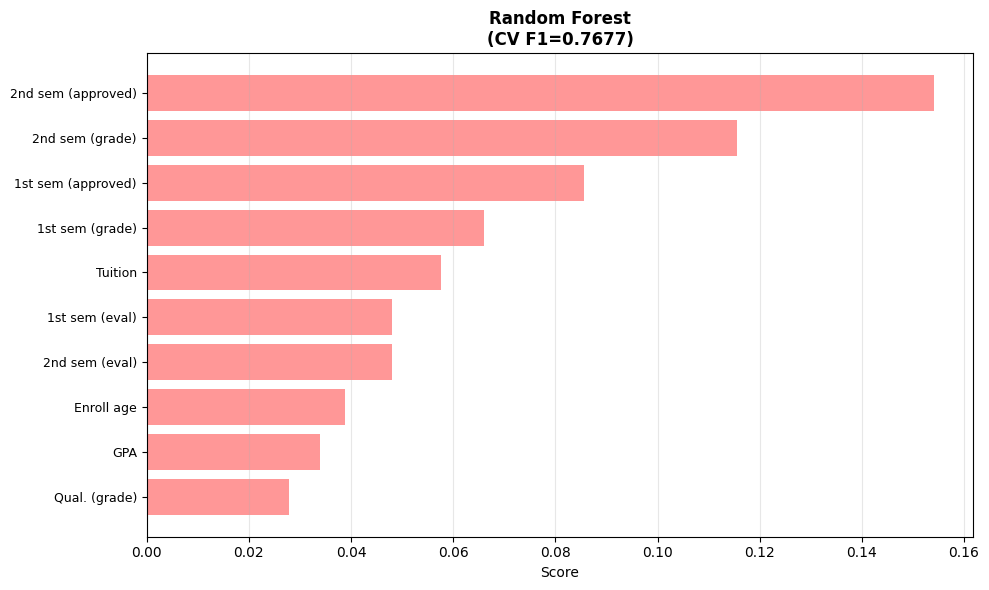

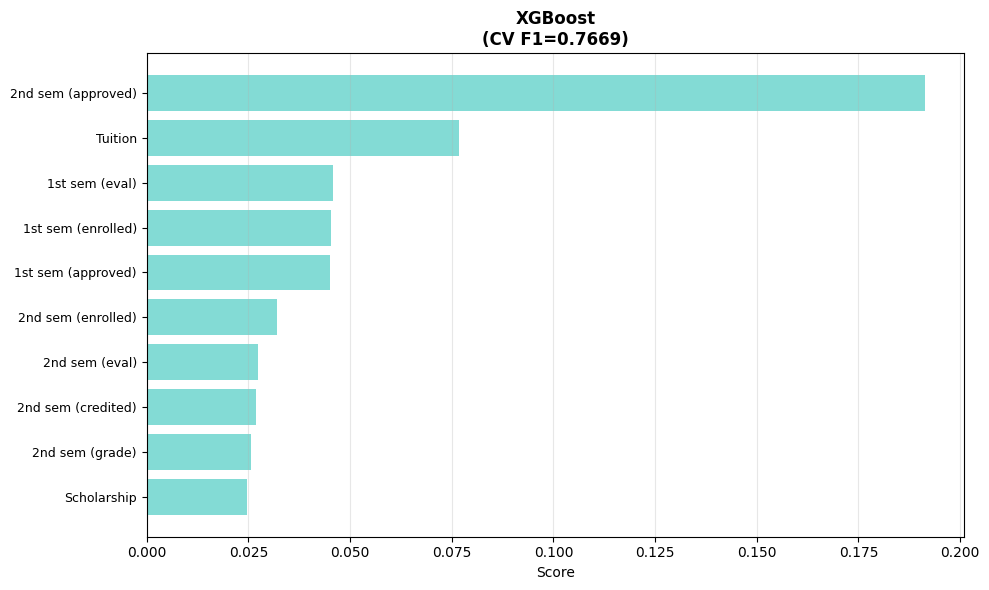

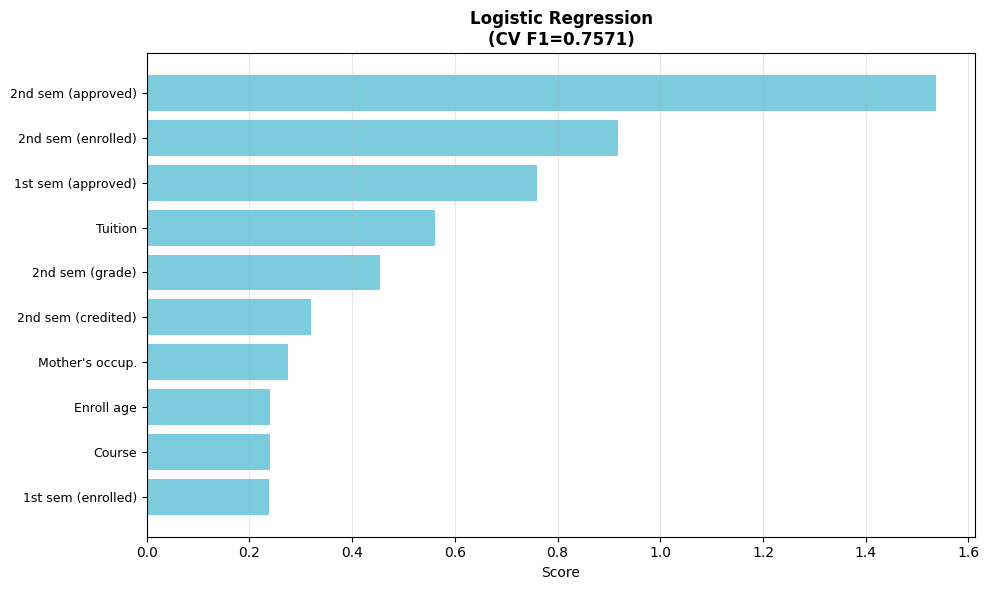

In [178]:
models_info = [
    ('Random Forest', rf_importance.head(12), '#FF6B6B', 0.7677),
    ('XGBoost', xgb_importance.head(12), '#4ECDC4', 0.7669),
    ('Logistic Regression', lr_coef.head(12), '#45B7D1', 0.7571),
]

# Create 3 individual plots
for title, data, color, f1_score in models_info:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(data)), data.iloc[:, 1], color=color, alpha=0.7)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['Feature'], fontsize=9)
    ax.set_xlabel('Score', fontsize=10)
    ax.set_title(f'{title}\n(CV F1={f1_score:.4f})', fontweight='bold', fontsize=12)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### Evaluation Metrics

In [179]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

def calculate_roc_auc_multiclass(y_true, y_pred_proba, labels):
    """
    Calculate ROC-AUC for multiclass using One-vs-Rest approach
    """
    if len(np.unique(y_true)) < len(labels):
        return np.nan
    y_bin = label_binarize(y_true, classes=labels)
    roc_auc_list = []
    for i, label in enumerate(labels):
        try:
            auc = roc_auc_score(y_bin[:, i], y_pred_proba[:, i])
            roc_auc_list.append(auc)
        except:
            pass
    return np.mean(roc_auc_list) if roc_auc_list else np.nan

# Rename best_models to avoid confusion with feature importance
tuned_models = best_models_tuned.copy()
evaluation_results = {}

# Evaluate all tuned models
for model_name in sorted(tuned_models.keys()):
    dataset_name = model_name.split('_')[-1]
    model = tuned_models[model_name]
    
    # Determine scale type and get test data
    if 'LogReg' in model_name:
        X_test = datasets_dict[dataset_name]['scaled']['X_test']
        y_test = datasets_dict[dataset_name]['scaled']['y_test']
    else:
        X_test = datasets_dict[dataset_name]['unscaled']['X_test']
        y_test = datasets_dict[dataset_name]['unscaled']['y_test']
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Calculate metrics
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracy = accuracy_score(y_test, y_pred)
    labels = model.classes_
    roc_auc = calculate_roc_auc_multiclass(y_test, y_pred_proba, labels)
    
    evaluation_results[model_name] = {
        'F1': f1, 'Accuracy': accuracy, 'ROC-AUC': roc_auc,
        'y_pred': y_pred, 'y_test': y_test
    }
    print(f"{model_name:30s} | F1: {f1:.4f} | Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f}")

LogReg_Lasso_early             | F1: 0.5740 | Accuracy: 0.6260 | ROC-AUC: 0.7276
LogReg_Lasso_full              | F1: 0.7370 | Accuracy: 0.7605 | ROC-AUC: 0.8699
LogReg_Lasso_mid               | F1: 0.6971 | Accuracy: 0.7356 | ROC-AUC: 0.8450
LogReg_Ridge_early             | F1: 0.5744 | Accuracy: 0.6249 | ROC-AUC: 0.7278
LogReg_Ridge_full              | F1: 0.7571 | Accuracy: 0.7718 | ROC-AUC: 0.8779
LogReg_Ridge_mid               | F1: 0.7032 | Accuracy: 0.7345 | ROC-AUC: 0.8536
RandomForest_early             | F1: 0.5966 | Accuracy: 0.5966 | ROC-AUC: 0.7493
RandomForest_full              | F1: 0.7452 | Accuracy: 0.7390 | ROC-AUC: 0.8853
RandomForest_mid               | F1: 0.7293 | Accuracy: 0.7277 | ROC-AUC: 0.8611
XGBoost_early                  | F1: 0.6037 | Accuracy: 0.6192 | ROC-AUC: 0.7488
XGBoost_full                   | F1: 0.7672 | Accuracy: 0.7751 | ROC-AUC: 0.8943
XGBoost_mid                    | F1: 0.7269 | Accuracy: 0.7379 | ROC-AUC: 0.8702


#### Confusion Matrices

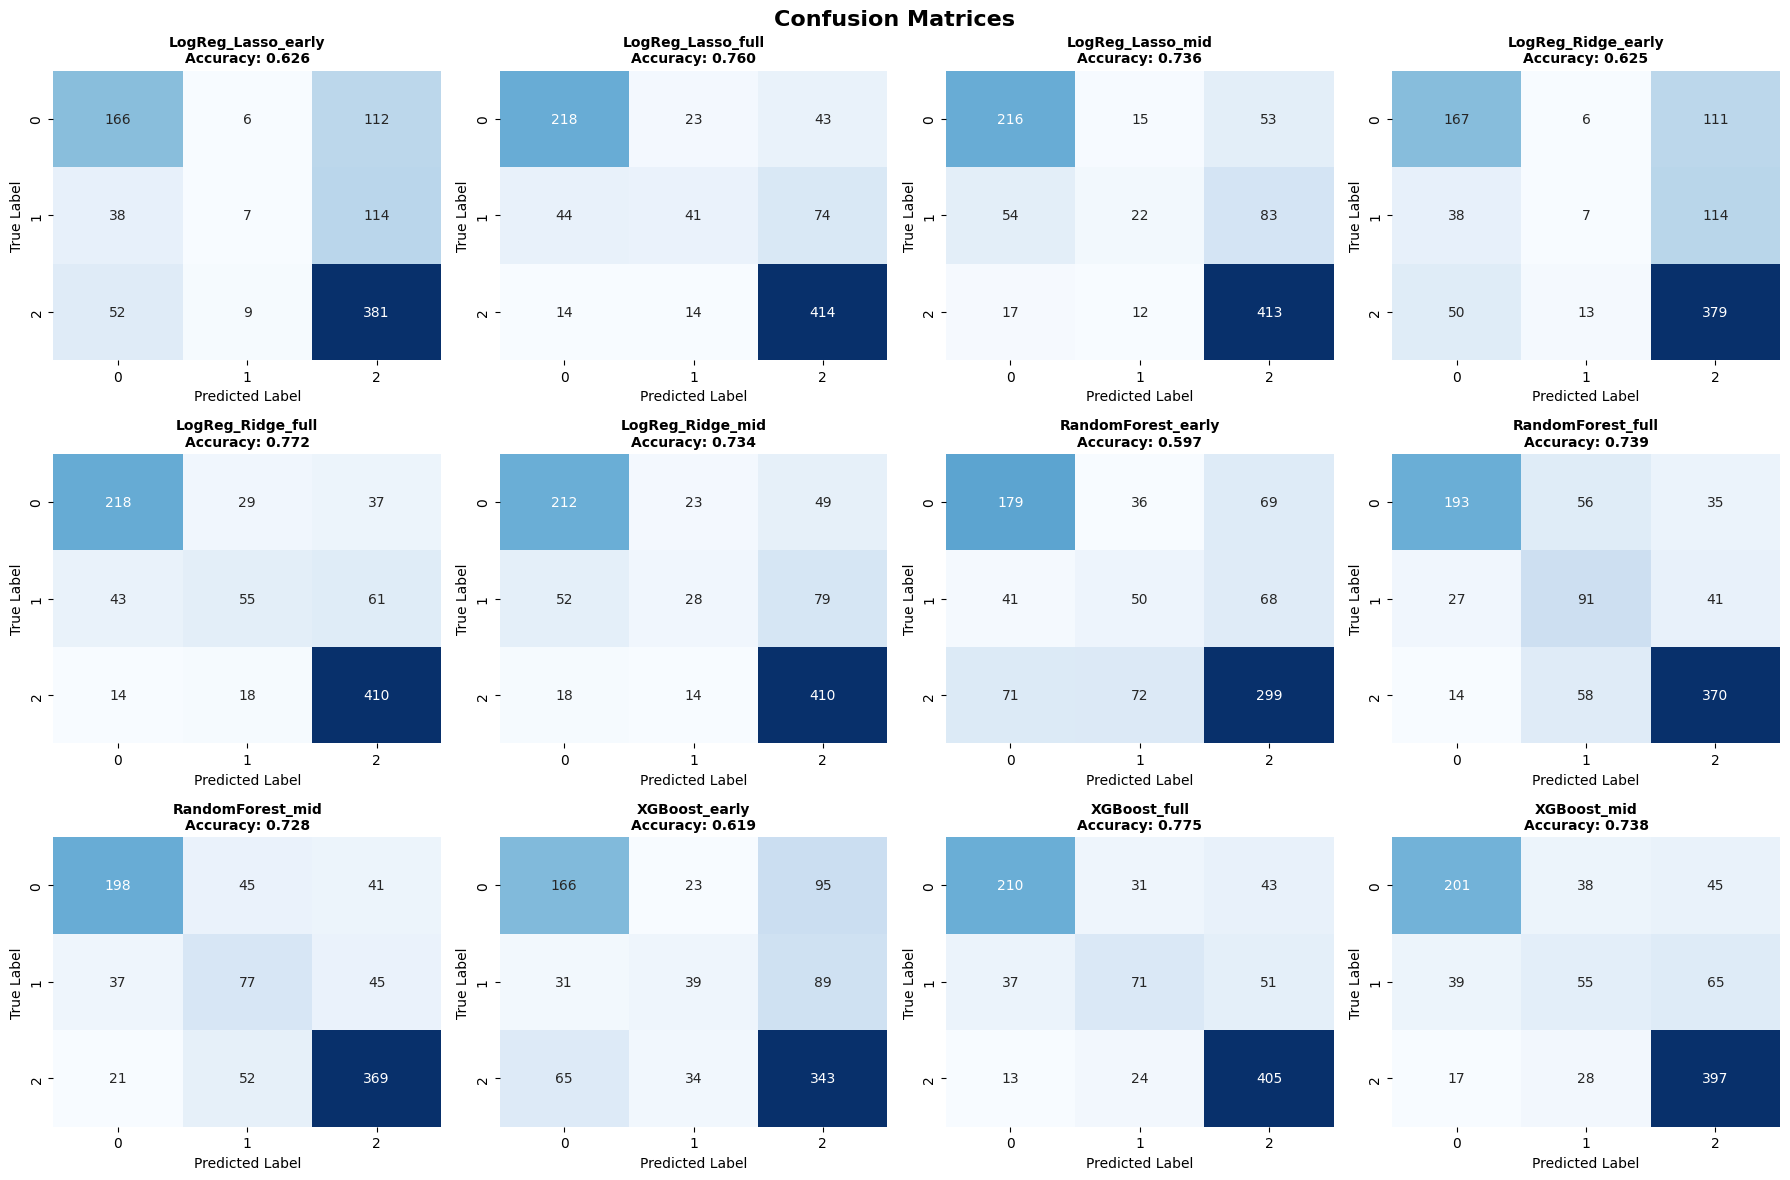

In [180]:
# Create confusion matrices for all tuned models
model_names_sorted = sorted(tuned_models.keys())
n_models = len(model_names_sorted)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
fig.suptitle(f'Confusion Matrices', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()

for idx, model_name in enumerate(model_names_sorted):
    model = tuned_models[model_name]
    y_test = evaluation_results[model_name]['y_test']
    y_pred = evaluation_results[model_name]['y_pred']
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=model.classes_, yticklabels=model.classes_,
                cbar=False)
    axes_flat[idx].set_title(f'{model_name}\nAccuracy: {evaluation_results[model_name]["Accuracy"]:.3f}',
                            fontsize=10, fontweight='bold')
    axes_flat[idx].set_ylabel('True Label')
    axes_flat[idx].set_xlabel('Predicted Label')

# Hide extra subplots
for idx in range(len(model_names_sorted), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Model Performance Summary

In [ ]:
# Algorithm mapping for optimized extraction
algorithm_map = {
    'LogReg_Ridge': 'LogReg (Ridge)',
    'LogReg_Lasso': 'LogReg (Lasso)',
    'RandomForest': 'Random Forest',
    'XGBoost': 'XGBoost'
}

# Create summary DataFrame from tuning and evaluation results
summary_data = [
    {
        'Model': model_name,
        'Algorithm': algorithm_map[model_name.rsplit('_', 1)[0]],
        'Dataset': model_name.split('_')[-1],
        'Tuning CV F1': tuning_results[model_name]['best_cv_score'],
        'Test F1': evaluation_results[model_name]['F1'],
        'Test Accuracy': evaluation_results[model_name]['Accuracy'],
        'Test ROC-AUC': evaluation_results[model_name]['ROC-AUC']
    }
    for model_name in sorted(tuned_models.keys())
]

summary_df = pd.DataFrame(summary_data)

print("Model Performance")
display(summary_df)

# Find best performing model
best_idx = summary_df['Test Accuracy'].idxmax()
best_model_row = summary_df.loc[best_idx]

print("Best Performing Model:")
print(f"Algorithm: {best_model_row['Algorithm']}")
print(f"Dataset: {best_model_row['Dataset']}")
print(f"Test Accuracy: {best_model_row['Test Accuracy']:.4f}")
print(f"Test F1 Score: {best_model_row['Test F1']:.4f}")
print(f"Test ROC-AUC: {best_model_row['Test ROC-AUC']:.4f}")

# Algorithm-wise performance comparison
print("\nAverage Algorithm Performance:")
algo_performance = summary_df.groupby('Algorithm')[['Test Accuracy', 'Test F1', 'Test ROC-AUC']].mean()
display(algo_performance)

# Dataset-wise performance comparison
print("\nAverage Dataset Performance:")
dataset_performance = summary_df.groupby('Dataset')[['Test Accuracy', 'Test F1', 'Test ROC-AUC']].mean()
display(dataset_performance)

Model Performance Summary


,Model,Algorithm,Dataset,Tuning CV F1,Test F1,Test Accuracy,Test ROC-AUC
0,LogReg_Lasso_early,LogReg (Lasso),early,0.571738,0.573986,0.625989,0.727629
1,LogReg_Lasso_full,LogReg (Lasso),full,0.740868,0.737015,0.760452,0.869898
2,LogReg_Lasso_mid,LogReg (Lasso),mid,0.703070,0.697071,0.735593,0.844966
3,LogReg_Ridge_early,LogReg (Ridge),early,0.574122,0.574373,0.624859,0.727756
4,LogReg_Ridge_full,LogReg (Ridge),full,0.750990,0.757104,0.771751,0.877874
5,LogReg_Ridge_mid,LogReg (Ridge),mid,0.709746,0.703204,0.734463,0.853594
6,RandomForest_early,Random Forest,early,0.626356,0.596635,0.596610,0.749260
7,RandomForest_full,Random Forest,full,0.767728,0.745156,0.738983,0.885317
8,RandomForest_mid,Random Forest,mid,0.733802,0.729322,0.727684,0.861056
9,XGBoost_early,XGBoost,early,0.626659,0.603657,0.619209,0.748768


Best Performing Model:
Algorithm: XGBoost
Dataset: full
Test Accuracy: 0.7751
Test F1 Score: 0.7672
Test ROC-AUC: 0.8943

Average Algorithm Performance:


,Test Accuracy,Test F1,Test ROC-AUC
Algorithm,,,
LogReg (Lasso),0.707345,0.669357,0.814164
LogReg (Ridge),0.710358,0.678227,0.819742
Random Forest,0.687759,0.690371,0.831878
XGBoost,0.710734,0.699244,0.837732



Average Dataset Performance:


,Test Accuracy,Test F1,Test ROC-AUC
Dataset,,,
early,0.616667,0.587162,0.738353
full,0.761582,0.751613,0.881836
mid,0.733898,0.714124,0.857447


In [182]:
# Feature impact analysis by algorithm
print("Feature Impact Analysis:")
for algo in ['LogReg (Ridge)', 'LogReg (Lasso)', 'Random Forest', 'XGBoost']:
    algo_df = summary_df[summary_df['Algorithm'] == algo].sort_values('Dataset')
    
    early_acc = algo_df[algo_df['Dataset'] == 'early']['Test Accuracy'].values[0] if len(algo_df[algo_df['Dataset'] == 'early']) > 0 else 0
    mid_acc = algo_df[algo_df['Dataset'] == 'mid']['Test Accuracy'].values[0] if len(algo_df[algo_df['Dataset'] == 'mid']) > 0 else 0
    full_acc = algo_df[algo_df['Dataset'] == 'full']['Test Accuracy'].values[0] if len(algo_df[algo_df['Dataset'] == 'full']) > 0 else 0
    
    sem1_impact = mid_acc - early_acc
    sem2_impact = full_acc - mid_acc
    total_impact = full_acc - early_acc
    
    print(f"\n{algo}:")
    print(f"  Early (baseline): {early_acc:.4f}")
    print(f"  Mid (+1st sem):   {mid_acc:.4f} ({sem1_impact:+.4f})")
    print(f"  Full (+2nd sem):  {full_acc:.4f} ({sem2_impact:+.4f})")
    print(f"  Total impact:     {total_impact:+.4f}")

Feature Impact Analysis:

LogReg (Ridge):
  Early (baseline): 0.6249
  Mid (+1st sem):   0.7345 (+0.1096)
  Full (+2nd sem):  0.7718 (+0.0373)
  Total impact:     +0.1469

LogReg (Lasso):
  Early (baseline): 0.6260
  Mid (+1st sem):   0.7356 (+0.1096)
  Full (+2nd sem):  0.7605 (+0.0249)
  Total impact:     +0.1345

Random Forest:
  Early (baseline): 0.5966
  Mid (+1st sem):   0.7277 (+0.1311)
  Full (+2nd sem):  0.7390 (+0.0113)
  Total impact:     +0.1424

XGBoost:
  Early (baseline): 0.6192
  Mid (+1st sem):   0.7379 (+0.1186)
  Full (+2nd sem):  0.7751 (+0.0373)
  Total impact:     +0.1559


## Visualizations: Model Performance


Marginal F1-Score Improvements by Algorithm:
     Algorithm  Early F1   Mid F1  Full F1  Demo→Sem1 (F1)  Sem1→Sem2 (F1)
LogReg (Ridge)  0.574373 0.703204 0.757104        0.128832        0.053900
LogReg (Lasso)  0.573986 0.697071 0.737015        0.123085        0.039945
 Random Forest  0.596635 0.729322 0.745156        0.132688        0.015833
       XGBoost  0.603657 0.726897 0.767179        0.123240        0.040282

Marginal Accuracy Improvements by Algorithm:
     Algorithm  Early Acc  Mid Acc  Full Acc  Demo→Sem1 (Acc)  Sem1→Sem2 (Acc)
LogReg (Ridge)   0.624859 0.734463  0.771751         0.109605         0.037288
LogReg (Lasso)   0.625989 0.735593  0.760452         0.109605         0.024859
 Random Forest   0.596610 0.727684  0.738983         0.131073         0.011299
       XGBoost   0.619209 0.737853  0.775141         0.118644         0.037288

KEY INSIGHTS:

Average F1 improvement (Demographics → +1st Semester): +0.1270 ⭐ MAJOR
Average F1 improvement (+1st Semester → +2nd Semest

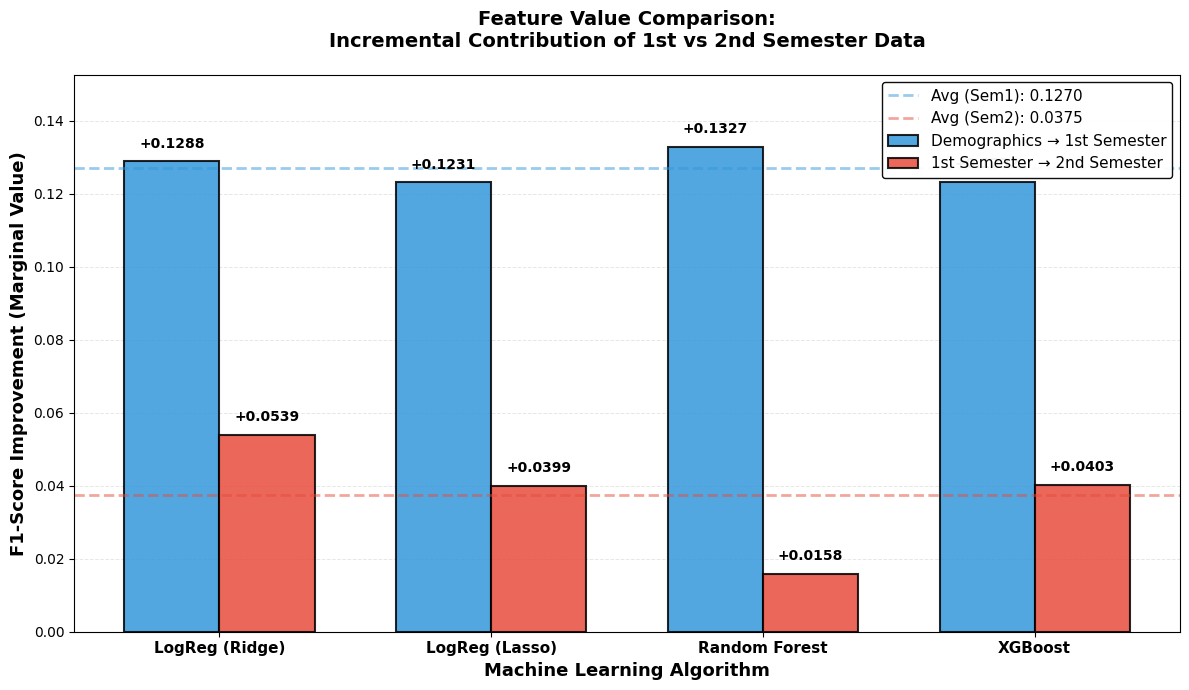


DETAILED MARGINAL VALUE BREAKDOWN

LogReg (Ridge):
  Early (Demographics only):
    F1-Score: 0.5744 | Accuracy: 0.6249
  Mid (+ 1st Semester): +0.1288 F1, +0.1096 Acc ⭐
    F1-Score: 0.7032 | Accuracy: 0.7345
  Full (+ 2nd Semester): +0.0539 F1, +0.0373 Acc
    F1-Score: 0.7571 | Accuracy: 0.7718

LogReg (Lasso):
  Early (Demographics only):
    F1-Score: 0.5740 | Accuracy: 0.6260
  Mid (+ 1st Semester): +0.1231 F1, +0.1096 Acc ⭐
    F1-Score: 0.6971 | Accuracy: 0.7356
  Full (+ 2nd Semester): +0.0399 F1, +0.0249 Acc
    F1-Score: 0.7370 | Accuracy: 0.7605

Random Forest:
  Early (Demographics only):
    F1-Score: 0.5966 | Accuracy: 0.5966
  Mid (+ 1st Semester): +0.1327 F1, +0.1311 Acc ⭐
    F1-Score: 0.7293 | Accuracy: 0.7277
  Full (+ 2nd Semester): +0.0158 F1, +0.0113 Acc
    F1-Score: 0.7452 | Accuracy: 0.7390

XGBoost:
  Early (Demographics only):
    F1-Score: 0.6037 | Accuracy: 0.6192
  Mid (+ 1st Semester): +0.1232 F1, +0.1186 Acc ⭐
    F1-Score: 0.7269 | Accuracy: 0.7379
  

In [ ]:
# Calculate marginal improvements by algorithm
algorithms = ['LogReg (Ridge)', 'LogReg (Lasso)', 'Random Forest', 'XGBoost']
marginal_analysis = []

for algo in algorithms:
    algo_data = summary_df[summary_df['Algorithm'] == algo].sort_values('Dataset')
    
    early_row = algo_data[algo_data['Dataset'] == 'early']
    mid_row = algo_data[algo_data['Dataset'] == 'mid']
    full_row = algo_data[algo_data['Dataset'] == 'full']
    
    if len(early_row) > 0 and len(mid_row) > 0 and len(full_row) > 0:
        early_f1 = early_row['Test F1'].values[0]
        mid_f1 = mid_row['Test F1'].values[0]
        full_f1 = full_row['Test F1'].values[0]
        
        early_acc = early_row['Test Accuracy'].values[0]
        mid_acc = mid_row['Test Accuracy'].values[0]
        full_acc = full_row['Test Accuracy'].values[0]
        
        # Marginal gains
        demo_to_sem1 = mid_f1 - early_f1
        sem1_to_sem2 = full_f1 - mid_f1
        
        demo_to_sem1_acc = mid_acc - early_acc
        sem1_to_sem2_acc = full_acc - mid_acc
        
        marginal_analysis.append({
            'Algorithm': algo,
            'Early F1': early_f1,
            'Mid F1': mid_f1,
            'Full F1': full_f1,
            'Demo→Sem1 (F1)': demo_to_sem1,
            'Sem1→Sem2 (F1)': sem1_to_sem2,
            'Early Acc': early_acc,
            'Mid Acc': mid_acc,
            'Full Acc': full_acc,
            'Demo→Sem1 (Acc)': demo_to_sem1_acc,
            'Sem1→Sem2 (Acc)': sem1_to_sem2_acc
        })

marginal_df = pd.DataFrame(marginal_analysis)

print("\nMarginal F1-Score Improvements by Algorithm:")
print(marginal_df[['Algorithm', 'Early F1', 'Mid F1', 'Full F1', 'Demo→Sem1 (F1)', 'Sem1→Sem2 (F1)']].to_string(index=False))

print("\nMarginal Accuracy Improvements by Algorithm:")
print(marginal_df[['Algorithm', 'Early Acc', 'Mid Acc', 'Full Acc', 'Demo→Sem1 (Acc)', 'Sem1→Sem2 (Acc)']].to_string(index=False))

# Key insights
print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)

avg_demo_to_sem1 = marginal_df['Demo→Sem1 (F1)'].mean()
avg_sem1_to_sem2 = marginal_df['Sem1→Sem2 (F1)'].mean()
max_demo_to_sem1 = marginal_df['Demo→Sem1 (F1)'].max()
max_sem1_to_sem2 = marginal_df['Sem1→Sem2 (F1)'].max()

print(f"\nAverage F1 improvement (Demographics → +1st Semester): +{avg_demo_to_sem1:.4f} ⭐ MAJOR")
print(f"Average F1 improvement (+1st Semester → +2nd Semester): +{avg_sem1_to_sem2:.4f}  (Diminishing)")
print(f"\nMaximum gains: Demo→Sem1 = +{max_demo_to_sem1:.4f} | Sem1→Sem2 = +{max_sem1_to_sem2:.4f}")
print(f"Ratio: Adding 1st semester is {max_demo_to_sem1/max_sem1_to_sem2:.1f}x more valuable than adding 2nd semester")

# Visualization: Feature Value Comparison (Single Graph)
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(algorithms))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, marginal_df['Demo→Sem1 (F1)'], width, 
               label='Demographics → 1st Semester', color='#3498db', alpha=0.85, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, marginal_df['Sem1→Sem2 (F1)'], width, 
               label='1st Semester → 2nd Semester', color='#e74c3c', alpha=0.85, edgecolor='black', linewidth=1.5)

# Customize axes
ax.set_ylabel('F1-Score Improvement (Marginal Value)', fontsize=13, fontweight='bold')
ax.set_xlabel('Machine Learning Algorithm', fontsize=13, fontweight='bold')
ax.set_title('Feature Value Comparison:\nIncremental Contribution of 1st vs 2nd Semester Data', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, fontsize=11, fontweight='bold')
ax.set_ylim([0, max(marginal_df['Demo→Sem1 (F1)'].max(), marginal_df['Sem1→Sem2 (F1)'].max()) * 1.15])

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

# Add legend with better positioning
ax.legend(fontsize=11, loc='upper right', framealpha=0.95, edgecolor='black', fancybox=True)

# Add value labels on bars with better formatting
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                f'+{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add average lines
avg_sem1 = marginal_df['Demo→Sem1 (F1)'].mean()
avg_sem2 = marginal_df['Sem1→Sem2 (F1)'].mean()
ax.axhline(y=avg_sem1, color='#3498db', linestyle='--', linewidth=2, alpha=0.5, label=f'Avg (Sem1): {avg_sem1:.4f}')
ax.axhline(y=avg_sem2, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.5, label=f'Avg (Sem2): {avg_sem2:.4f}')

# Update legend to include average lines
ax.legend(fontsize=11, loc='upper right', framealpha=0.95, edgecolor='black', fancybox=True)

plt.tight_layout()
plt.show()

# Print detailed breakdown
print("\n" + "=" * 80)
print("DETAILED MARGINAL VALUE BREAKDOWN")
print("=" * 80)
""")

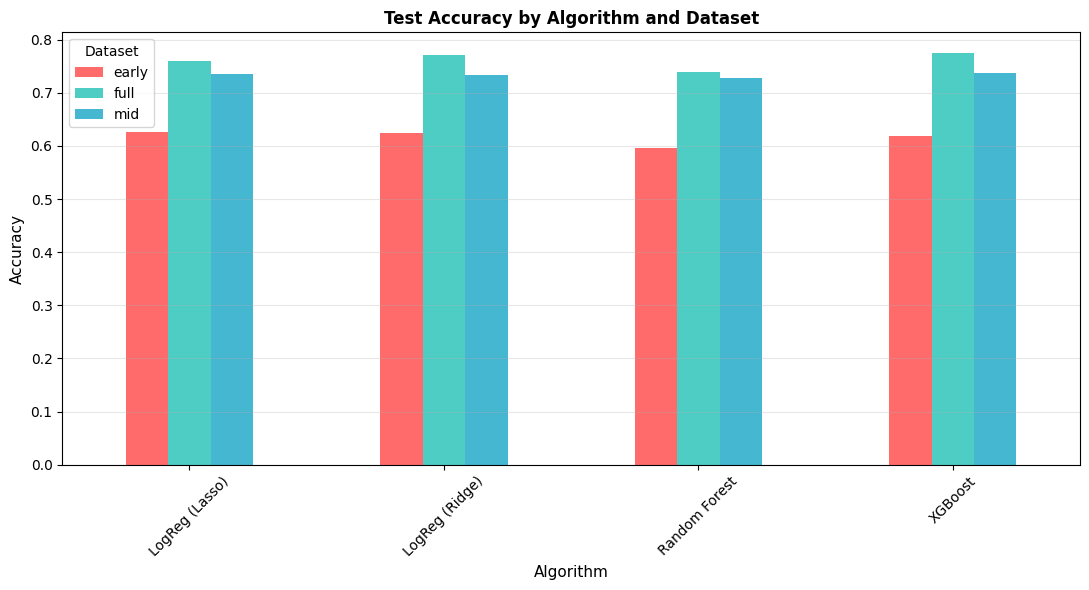

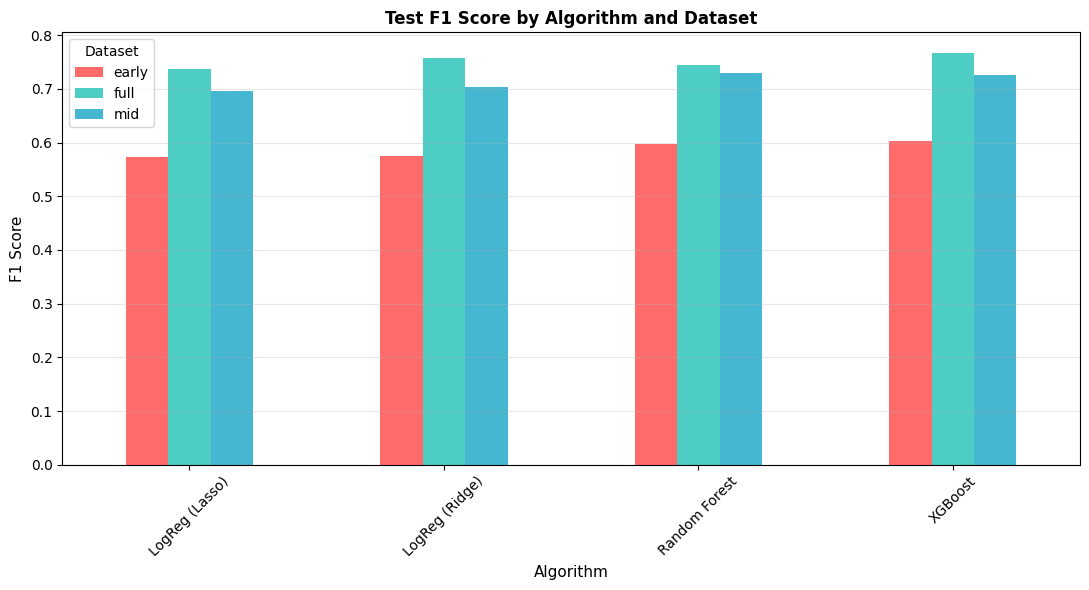

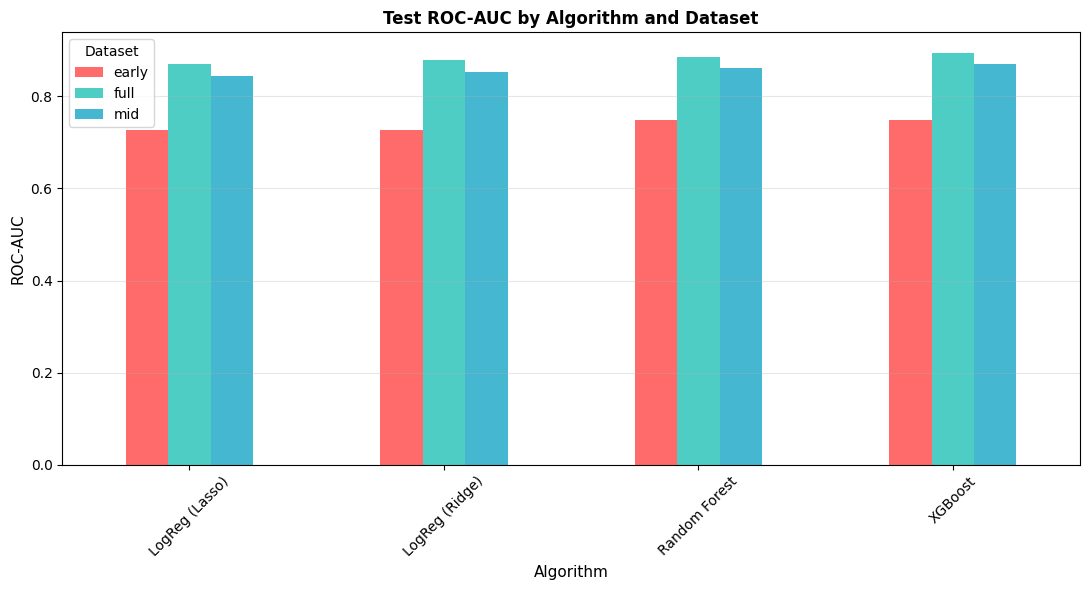

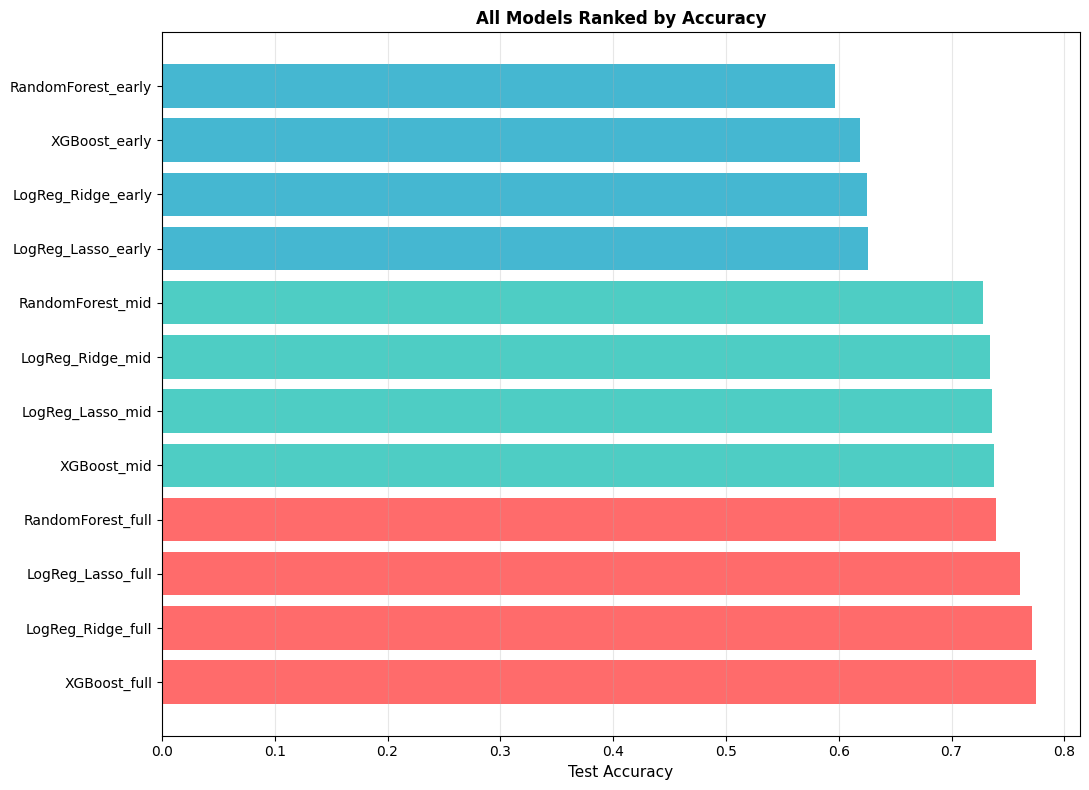

In [185]:
# Plot 1: Accuracy by Algorithm and Dataset
fig, ax = plt.subplots(figsize=(11, 6))
pivot_accuracy = summary_df.pivot_table(values='Test Accuracy', index='Algorithm', columns='Dataset')
pivot_accuracy.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Test Accuracy by Algorithm and Dataset', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xlabel('Algorithm', fontsize=11)
ax.legend(title='Dataset', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: F1 Score by Algorithm and Dataset
fig, ax = plt.subplots(figsize=(11, 6))
pivot_f1 = summary_df.pivot_table(values='Test F1', index='Algorithm', columns='Dataset')
pivot_f1.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Test F1 Score by Algorithm and Dataset', fontweight='bold', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_xlabel('Algorithm', fontsize=11)
ax.legend(title='Dataset', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: ROC-AUC by Algorithm and Dataset
fig, ax = plt.subplots(figsize=(11, 6))
pivot_roc = summary_df.pivot_table(values='Test ROC-AUC', index='Algorithm', columns='Dataset')
pivot_roc.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Test ROC-AUC by Algorithm and Dataset', fontweight='bold', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_xlabel('Algorithm', fontsize=11)
ax.legend(title='Dataset', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot 4: All models - ranked by Accuracy
fig, ax = plt.subplots(figsize=(11, 8))
summary_sorted = summary_df.sort_values('Test Accuracy', ascending=False)
colors = ['#45B7D1' if 'early' in m else '#4ECDC4' if 'mid' in m else '#FF6B6B' for m in summary_sorted['Model']]
ax.barh(range(len(summary_sorted)), summary_sorted['Test Accuracy'], color=colors)
ax.set_yticks(range(len(summary_sorted)))
ax.set_yticklabels(summary_sorted['Model'], fontsize=10)
ax.set_xlabel('Test Accuracy', fontsize=11)
ax.set_title('All Models Ranked by Accuracy', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()